# Analysis by using a second video

In [1]:
import sys
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import polars as pl
from datetime import datetime
    
sys.path.insert(1, os.path.dirname(os.getcwd()))
from pd_support import *
from scipy.spatial.transform import Rotation as R
import polars as pl
import os
from scipy.interpolate import interp1d
from joblib import Parallel, delayed
import toml

In [2]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_fov = "160_fov"

_recording_folder_name = "ref_recording_single_april_diwakar"

_reference_recording_folder = os.path.join(
    _pth, _parent_folder, _recording_folder_name
)
_reference_file = os.path.join(_reference_recording_folder, "webcam_color.msgpack")

_timestamp_file = os.path.join(_reference_recording_folder, "webcam_timestamp.msgpack")
with open(_timestamp_file, "rb") as f:
    _metadata = list(mp.Unpacker(f, object_hook=mpn.decode))
    _timestamp = np.array(_metadata)[:,1]
    _sync_pulse = np.array(_metadata)[:,0]

### load calibration combinations

In [3]:
calib_data = toml.load(open(os.path.join(_reference_recording_folder, "diwakar_calibration.toml"), "r"))
camera_matrix = np.array(calib_data['calibration']['camera_matrix'])
dist_coeffs = np.array(calib_data['calibration']['dist_coeffs'])

In [4]:
_ref_video_length = 0

for _ in mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode):
    _ref_video_length += 1

print('video length, ', _ref_video_length)

video length,  6078


In [5]:
ARUCO_PARAMETERS = aruco.DetectorParameters()
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36h11)
detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
markerLength = 0.05
markerSeperation = 0.01

board = aruco.GridBoard(
    size=[1, 1],
    markerLength=markerLength,
    markerSeparation=markerSeperation,
    dictionary=ARUCO_DICT,
)

def estimate_pose_single_markers(
    corners, marker_size, camera_matrix, distortion_coefficients = np.zeros((5, 1))
):
    marker_points = np.array(
        [
            [-marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, -marker_size / 2, 0],
            [-marker_size / 2, -marker_size / 2, 0],
        ],
        dtype=np.float32,
    )
    rvecs, tvecs = [], []
    for corner in corners:
        _, r, t = cv2.solvePnP(
            marker_points,
            corner,
            camera_matrix,
            distortion_coefficients,
            flags=cv2.SOLVEPNP_ITERATIVE,
        )
        if r is not None and t is not None:
            rvecs.append(r.reshape(1, 3).tolist())
            tvecs.append(t.reshape(1, 3).tolist())
        else:
            rvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
            tvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
    return np.array(rvecs, dtype=np.float32), np.array(tvecs, dtype=np.float32)

## load clalibration data

In [6]:
# selecting random 50 frames
np.random.seed(9)
_random_reference_frames_idx = np.random.choice(_ref_video_length, 300)

_ref_data = mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode)

# _ref_frames = []

new_camera_matrix = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    camera_matrix,
    dist_coeffs,
    (1280, 800),
    np.eye(3),
    balance=1.0,
)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    camera_matrix,
    dist_coeffs,
    np.eye(3),
    new_camera_matrix,
    (1280, 800),
    cv2.CV_16SC2,
)

ar_results = {'corners': [], 'ids': [], 'rejected': []}

tvecs = []
rvecs = []
for idx, _frame in tqdm(enumerate(_ref_data)):
    # if idx in _random_reference_frames_idx:

        # _frame = cv2.rotate(_frame, cv2.ROTATE_180)
    # _frame = cv2.flip(_frame, 1)

    # undistort the image using the calibration parameters
    _frame = cv2.remap(_frame, map1, map2, cv2.INTER_LINEAR)
    res = detector.detectMarkers(_frame,)   
    res = detector.refineDetectedMarkers(_frame, board, res[0], res[1], res[2])
    ar_results['corners'].append(res[0])
    ar_results['ids'].append(res[1])
    ar_results['rejected'].append(res[2])

    # i want only id 12
    if res[1] is not None and 12 in res[1]:
        idx_12 = np.where(res[1] == 12)[0][0]
        rvec, tvec = estimate_pose_single_markers(
            corners=[res[0][idx_12].reshape(-1, 1, 2)],
            marker_size=markerLength,
            camera_matrix=new_camera_matrix,
            distortion_coefficients=np.zeros((5, 1))
        )
        tvecs.append(tvec[0])
        rvecs.append(rvec[0])
    else:
        tvecs.append(np.array([[np.nan, np.nan, np.nan]]))
        rvecs.append(np.array([[np.nan, np.nan, np.nan]]))


0it [00:00, ?it/s]

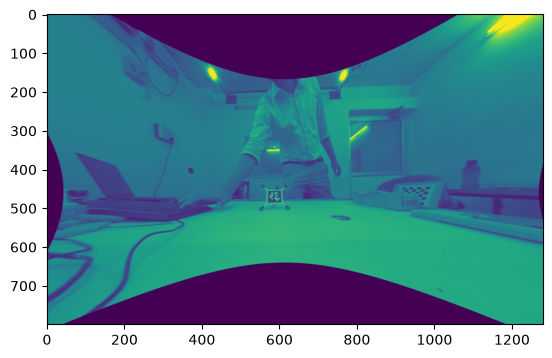

In [7]:
plt.imshow(_frame)

In [8]:
ar_df = {"time": _timestamp, "sync": _sync_pulse}
ar_df = pl.from_dict(ar_df)
if type(ar_df["time"][0]) is not datetime:
    ar_df = ar_df.with_columns(pl.col("time").str.to_datetime())

In [9]:
mocap_df, st_time = read_rigid_body_csv(
    os.path.join(_reference_recording_folder, f"{_recording_folder_name}.csv")
)
mocap_df = add_datetime_col(mocap_df, st_time, "seconds")
mocap_df = pl.from_pandas(mocap_df)

In [10]:
tr = get_rb_marker_name(5)
tl = get_rb_marker_name(6)
br = get_rb_marker_name(4)
bl = get_rb_marker_name(1)

In [11]:
ar_df['sync'][0]

'0'

In [12]:
ar_df = ar_df.with_columns(
    pl.col("sync").cast(pl.Int8).cast(pl.Boolean)
)

In [13]:
start_pulse = ar_df["sync"].arg_true().head(1).item()
offset = (~ar_df["sync"].slice(start_pulse)).arg_true().head(1).item()

end_pulse = start_pulse + offset

print(f"Start pulse: {start_pulse}, End pulse: {end_pulse}")
ar_df = ar_df[start_pulse:end_pulse]
ar_corners = ar_results['corners'][start_pulse:end_pulse]
ids = ar_results['ids'][start_pulse:end_pulse]

_time_diff = mocap_df["time"][0] - ar_df["time"][0]

ar_df = ar_df.with_columns([(pl.col("time") + _time_diff).alias("time")])

Start pulse: 343, End pulse: 5895


In [14]:
ar_tvecs = tvecs[start_pulse:end_pulse]
ar_rvecs = rvecs[start_pulse:end_pulse]
ar_tvecs = np.array(ar_tvecs)
ar_rvecs = np.array(ar_rvecs)

In [15]:
mocap_df["time"][0]

datetime.datetime(2026, 6, 18, 14, 47, 11, 941000)

In [16]:
ar_df["time"][0]

datetime.datetime(2026, 6, 18, 14, 47, 11, 941000)

In [17]:
_time_diff

datetime.timedelta(days=-1, seconds=86399, microseconds=805565)

In [18]:
mocap_mean = {"x": [], "y": [], "z": []}
mocap_mean["x"] = mocap_df[[tr["x"], tl["x"], br["x"], bl["x"]]].to_numpy().mean(axis=1)
mocap_mean["y"] = mocap_df[[tr["y"], tl["y"], br["y"], bl["y"]]].to_numpy().mean(axis=1)
mocap_mean["z"] = mocap_df[[tr["z"], tl["z"], br["z"], bl["z"]]].to_numpy().mean(axis=1)

mocap_qt_0 = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]][0].to_numpy()

mocap_rotation = R.from_quat(mocap_qt_0).as_matrix()

mocap_mean = pl.from_dict(mocap_mean)

mt_dict = {"x": [], "y": [], "z": []}
rmat_m = mocap_rotation[0]

for i in range(len(mocap_df["time"])):
    tvec_ar = rmat_m.T @ (
        mocap_mean[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - mocap_mean[["x", "y", "z"]][0].to_numpy().reshape(3, 1)
    )
    tvec_ar = tvec_ar.T[0]
    mt_dict["x"].append(tvec_ar[0])
    mt_dict["y"].append(tvec_ar[1])
    mt_dict["z"].append(tvec_ar[2])

mt_dict["time"] = mocap_df["time"]

In [19]:
mc_angle_arr = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy()
mocap_angle = []
mc_ang_x = []
mc_ang_y = []
mc_ang_z = []
for _a in mc_angle_arr:
    try:
        _ax, _ay, _az = R.from_matrix(
            mocap_rotation[0].T @ R.from_quat(_a).as_matrix()
        ).as_euler("xyz", degrees=True)
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)
    except:
        _ax, _ay, _az = R.from_matrix(mocap_rotation[0].T @ np.eye(3)).as_euler(
            "xyz", degrees=True
        )
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)

## Interoplating

In [20]:
mocap = pl.from_dict(mt_dict)

x1 = interp1d(mocap["time"].dt.epoch(), mocap["x"], fill_value="extrapolate")
y1 = interp1d(mocap["time"].dt.epoch(), mocap["y"], fill_value="extrapolate")
z1 = interp1d(mocap["time"].dt.epoch(), mocap["z"], fill_value="extrapolate")

ax = interp1d(mocap["time"].dt.epoch(), mc_ang_x, fill_value="extrapolate")
ay = interp1d(mocap["time"].dt.epoch(), mc_ang_y, fill_value="extrapolate")
az = interp1d(mocap["time"].dt.epoch(), mc_ang_z, fill_value="extrapolate")

mocap_ip = {"time": ar_df["time"]}
mocap_ip["x"] = x1(ar_df["time"].dt.epoch())
mocap_ip["y"] = y1(ar_df["time"].dt.epoch())
mocap_ip["z"] = z1(ar_df["time"].dt.epoch())
mocap_ip["rx"] = ax(ar_df["time"].dt.epoch())
mocap_ip["ry"] = ay(ar_df["time"].dt.epoch())
mocap_ip["rz"] = az(ar_df["time"].dt.epoch())

R_opt = np.array([
    [ 0.98458659, -0.03644425,  0.17105865],
    [ 0.07710029,  0.96832946, -0.23747339],
    [-0.15698659,  0.24700179,  0.95621406],
])
t_opt = np.array([-0.00798871, -0.01317108, 0.00632256])

# stack x,y,z -> (N,3), align, write back
mocap_array = np.column_stack([mocap_ip["x"], mocap_ip["y"], mocap_ip["z"]])
aligned_mocap = (R_opt @ mocap_array.T).T + t_opt
mocap_ip["x"], mocap_ip["y"], mocap_ip["z"] = (
    aligned_mocap[:, 0],
    aligned_mocap[:, 1],
    aligned_mocap[:, 2],
)

mocap_ip = pl.from_dict(mocap_ip)

In [21]:
default_ids = [12, 14, 20]

# Evaluation section

### Align mocap

In [22]:
import numpy as np
from scipy.spatial.transform import Rotation as R_scipy

def align_trajectories(source, target):
    """
    Aligns source array to target array using the Kabsch algorithm.
    Both arrays should be of shape (N, 3).
    Returns the rotation matrix, translation vector, and Euler angles in degrees.
    """
    # 1. Calculate centroids and center the data
    centroid_source = np.mean(source, axis=0)
    centroid_target = np.mean(target, axis=0)
    source_centered = source - centroid_source
    target_centered = target - centroid_target

    # 2. Calculate covariance matrix H and perform SVD
    H = source_centered.T @ target_centered
    U, S, Vt = np.linalg.svd(H)

    # 3. Calculate the optimal rotation matrix R
    R = Vt.T @ U.T

    # 4. Handle reflection case
    if np.linalg.det(R) < 0:
        Vt[2, :] *= -1
        R = Vt.T @ U.T

    # 5. Calculate the translation vector t
    t = centroid_target - R @ centroid_source

    # ---------------------------------------------------------
    # NEW: Convert the 3x3 Rotation Matrix to Euler Angles
    # ---------------------------------------------------------
    # We use 'xyz' order (pitch, yaw, roll). 
    # The order matters in 3D space, but 'xyz' is the most intuitive 
    # for reading "rotation around X, then Y, then Z".
    rotation_obj = R_scipy.from_matrix(R)
    angles_degrees = rotation_obj.as_euler('xyz', degrees=True)

    return R, t, angles_degrees


In [23]:
# all_corners_list = []
# corner_counts = []
# print("Filtering corners for ID 12...")
# for _corner, _id in zip(ar_corners, ids):
#     try:
#         id_index = _id.reshape(-1).tolist().index(12)
#         all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
#         corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
#     except:
#         corner_counts.append(0)
# all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)


# tvecs = []
# rvecs = []

# for counts, corners in zip(corner_counts, all_corners_list):
#     if counts > 0:
#         rvec, tvec = estimate_pose_single_markers(
#             corners=[corners.reshape(4, 1, 2)],
#             marker_size=markerLength,
#             camera_matrix=new_camera_matrix,
#             distortion_coefficients=np.zeros((5, 1)),
#         )
#         tvecs.append(tvec[0][0])
#         rvecs.append(rvec[0][0])
#     else:
#         tvecs.append(np.array([np.nan, np.nan, np.nan]))
#         rvecs.append(np.array([np.nan, np.nan, np.nan]))

tvecs = ar_tvecs.reshape(-1, 3)
rvecs = ar_rvecs.reshape(-1, 3)

# Vectorize transformation calculations using first valid marker as reference
rmat = cv2.Rodrigues(rvecs[1])[0]
rmat_T = rmat.T

# Vectorized translation transformation
tvec_diff = tvecs - tvecs[0]
tvec_transformed = (rmat_T @ tvec_diff.T).T

# axis flipped
transformed_tvecs = tvec_transformed.copy()
# transformed_tvecs[:, 0] = tvec_transformed[:, 1]
# transformed_tvecs[:, 1] = tvec_transformed[:, 2]
# transformed_tvecs[:, 2] = tvec_transformed[:, 0]

# Vectorize error calculations
_ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:, 0]))
_ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:, 0]))
_ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:, 0]))

_mean_err = np.nanmean([_ex, _ey, _ez])

# filtering out 95th percentile

_ex_arr = np.abs(transformed_tvecs[:, 0] - aligned_mocap[:, 0])
_px = np.nanpercentile(_ex_arr, 95)
_ex_p = np.nanmax(_ex_arr[_ex_arr <= _px])

_ey_arr = np.abs(transformed_tvecs[:, 1] - aligned_mocap[:, 0])
_py = np.nanpercentile(_ey_arr, 95)
_ey_p = np.nanmax(_ey_arr[_ey_arr <= _py])
    
_ez_arr = np.abs(transformed_tvecs[:, 2] - aligned_mocap[:, 0])
_pz = np.nanpercentile(_ez_arr, 95)
_ez_p = np.nanmax(_ez_arr[_ez_arr <= _pz])

_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:, 0]))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:, 0]))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:, 0]))

print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")
print(f"Max error 95th percentile: X={_ex_p}, Y={_ey_p}, Z={_ez_p}")

Max error: X=0.04055277677975758, Y=0.6203001841959617, Z=0.36162427498075184
Max error 95th percentile: X=0.01986158524575124, Y=0.42158773791457643, Z=0.2982177949504091


In [24]:
print(R_opt, t_opt)

[[ 0.98458659 -0.03644425  0.17105865]
 [ 0.07710029  0.96832946 -0.23747339]
 [-0.15698659  0.24700179  0.95621406]] [-0.00798871 -0.01317108  0.00632256]


In [25]:
_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:, 0]))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:, 1]))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:, 2]))
print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")

Max error: X=0.04055277677975758, Y=0.0405689577196815, Z=0.031412602543828216


### Evaluating a section to see everything is right

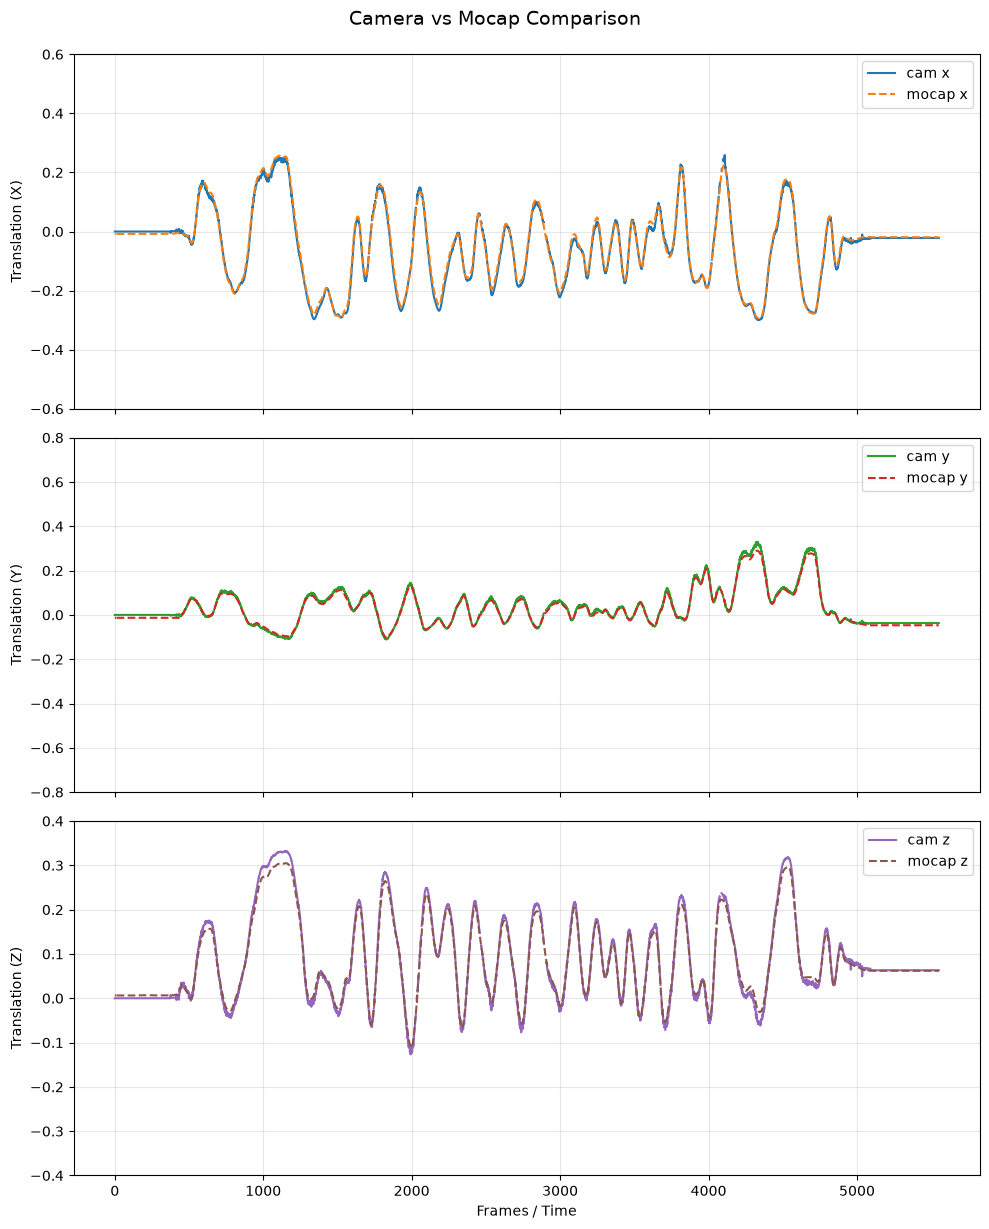

In [26]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (rows), sharing the same x-axis
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Subplot for X
axes[0].plot(tvec_transformed[:, 0], label="cam x", color='tab:blue')
axes[0].plot(aligned_mocap[:, 0], label="mocap x", color='tab:orange', linestyle='--')
axes[0].set_ylabel("Translation (X)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.6, 0.6)


# Subplot for Y
axes[1].plot(tvec_transformed[:, 1], label="cam y", color='tab:green')
axes[1].plot(aligned_mocap[:, 1], label="mocap y", color='tab:red', linestyle='--')
axes[1].set_ylabel("Translation (Y)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.8, 0.8)

# Subplot for Z
axes[2].plot(tvec_transformed[:, 2], label="cam z", color='tab:purple')
axes[2].plot(aligned_mocap[:,2], label="mocap z", color='tab:brown', linestyle='--')
# axes[2].plot(mocap_z, label="mocap z", color='tab:brown', linestyle='--')
axes[2].set_ylabel("Translation (Z)")
axes[2].set_xlabel("Frames / Time")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.4, 0.4)

# Adjust layout to prevent label overlapping
plt.tight_layout()
plt.suptitle("Camera vs Mocap Comparison", y=1.02, fontsize=14)
plt.show()


/tmp/ipykernel_191689/672892687.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


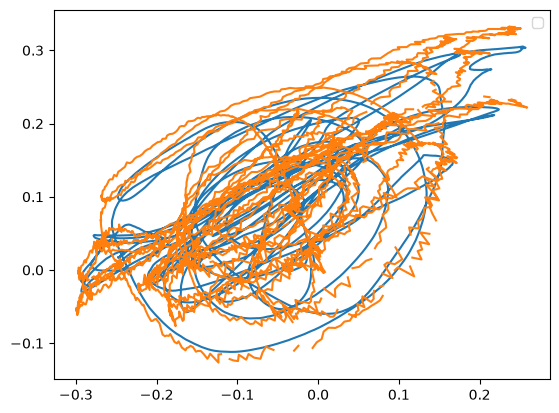

In [30]:
plt.plot(aligned_mocap[:,0], aligned_mocap[:,2])
# plt.plot(mocap_x, mocap_z)
plt.plot(tvec_transformed[:, 0], tvec_transformed[:, 2])
plt.legend()
plt.show()